In [ ]:
! pip install torch torchvision qiskit qiskit-machine-learning matplotlib seaborn scikit-learn tabulate


In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
from qiskit import QuantumCircuit
from qiskit.visualization import circuit_drawer
from qiskit.circuit import ParameterVector
from qiskit.primitives import Sampler
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.connectors import TorchConnector

In [3]:
from sklearn.metrics import (
    confusion_matrix, 
    precision_score, 
    recall_score, 
    f1_score, 
    accuracy_score,
    roc_curve, 
    auc,
    classification_report
)
from tabulate import tabulate


In [4]:
class Config:
    category = "bottle"
    base_path = "/kaggle/input/mvtec-ad"
    img_size = 64
    latent_dim = 4
    num_qubits = 4
    depth = 2
    batch_size = 16
    epochs = 50
    learning_rate_g = 0.00015
    learning_rate_d = 0.000075

config = Config()


In [5]:
class MVTecADLoader(Dataset):
    def __init__(self, root_dir):
        self.image_files = [os.path.join(root_dir, f) for f in os.listdir(root_dir) 
                            if f.lower().endswith(('.png', 'jpg', 'jpeg'))]
        self.transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        return self.transform(Image.open(self.image_files[idx]).convert('L')), 0


In [6]:
def create_quantum_circuit():
    input_params = ParameterVector('input', config.latent_dim)
    weights = ParameterVector('weight', config.num_qubits * config.depth)

    qc = QuantumCircuit(config.num_qubits)

    # Input encoding
    for i in range(config.latent_dim):
        qc.rx(input_params[i], i)
    
    # Parametrized layers
    weight_idx = 0
    for _ in range(config.depth):
        for qubit in range(config.num_qubits):
            qc.ry(weights[weight_idx], qubit)
            weight_idx += 1

    return qc

In [7]:
class QuantumGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.qc = create_quantum_circuit()
        params = self.qc.parameters
        
        self.qnn = SamplerQNN(
            circuit=self.qc,
            input_params=params[:config.latent_dim],
            weight_params=params[config.latent_dim:],
            sampler=Sampler(),
            output_shape=2**config.num_qubits,
            input_gradients=True
        )
        
        self.hybrid_layer = TorchConnector(
            self.qnn,
            initial_weights=torch.randn(len(params)-config.latent_dim)*0.01
        )
        
        self.post_process = nn.Linear(16, config.img_size**2)

    def forward(self, z):
        z = z.view(-1, config.latent_dim)
        return self.post_process(self.hybrid_layer(z)).view(-1, 1, 64, 64)


In [8]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*64*1, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


In [9]:
def plot_loss_curves(g_losses, d_losses):
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.plot(g_losses, label='Generator Loss')
    plt.title('Generator Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')

    plt.subplot(1,2,2)
    plt.plot(d_losses, label='Discriminator Loss')
    plt.title('Discriminator Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.tight_layout()
    plt.show()

In [10]:
def plot_confusion_matrix(true_labels, predicted_labels):
    cm = confusion_matrix(true_labels, predicted_labels)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix for Anomaly Detection')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()


In [11]:
def print_performance_metrics(true_labels, predicted_labels):
    # Compute performance metrics
    precision = precision_score(true_labels, predicted_labels)
    recall = recall_score(true_labels, predicted_labels)
    f1 = f1_score(true_labels, predicted_labels)
    accuracy = accuracy_score(true_labels, predicted_labels)

    # Create performance metrics table
    metrics_table = {
        'Metric': ['Precision', 'Recall', 'F1 Score', 'Accuracy'],
        'Value': [
            f'{precision:.4f}', 
            f'{recall:.4f}', 
            f'{f1:.4f}', 
            f'{accuracy:.4f}'
        ]
    }
    
    # Print as a formatted table
    print("\nPerformance Metrics:")
    print(tabulate(metrics_table, headers='keys', tablefmt='pretty'))


In [12]:
def visualize_anomalies(original_images, reconstructed_images, anomaly_scores):
    plt.figure(figsize=(15, 5*len(original_images)))
    
    for i in range(len(original_images)):
        plt.subplot(len(original_images), 3, i*3 + 1)
        plt.imshow(original_images[i].squeeze(), cmap='gray')
        plt.title(f'Original Image {i+1}')
        
        plt.subplot(len(original_images), 3, i*3 + 2)
        plt.imshow(reconstructed_images[i].squeeze(), cmap='gray')
        plt.title(f'Reconstructed Image {i+1}')
        
        plt.subplot(len(original_images), 3, i*3 + 3)
        anomaly_map = np.abs(original_images[i] - reconstructed_images[i])
        plt.imshow(anomaly_map.squeeze(), cmap='hot')
        plt.title(f'Anomaly Map (Score: {anomaly_scores[i]:.4f})')
    
    plt.tight_layout()
    plt.show()

In [13]:
def plot_roc_curve(true_labels, predicted_scores):
    fpr, tpr, thresholds = roc_curve(true_labels, predicted_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.show()


In [14]:
def train_qgan():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    gen = QuantumGenerator().to(device)
    disc = Discriminator().to(device)

    opt_g = torch.optim.RMSprop(gen.parameters(), lr=config.learning_rate_g)
    opt_d = torch.optim.RMSprop(disc.parameters(), lr=config.learning_rate_d)

    train_path = f"{config.base_path}/{config.category}/train/good"
    train_set = MVTecADLoader(train_path)
    train_loader = torch.utils.data.DataLoader(
        train_set,
        batch_size=config.batch_size,
        shuffle=True,
        drop_last=True,
        num_workers=2
    )

    g_losses = []
    d_losses = []

    print("Training started...")
    for epoch in range(config.epochs):
        epoch_g_loss = 0
        epoch_d_loss = 0

        for real_imgs, _ in train_loader:
            real_imgs = real_imgs.to(device)
            
            # Train Discriminator
            z = torch.randn(config.batch_size*4).view(-1,4).to(device)
            
            with torch.no_grad():
                fake_imgs = gen(z)
            
            real_loss = -torch.mean(disc(real_imgs))
            fake_loss = -torch.mean(1 - disc(fake_imgs))
            
            d_loss = real_loss + fake_loss
            
            disc.zero_grad()
            d_loss.backward()
            opt_d.step()
            
            # Train Generator (Hybrid Backprop)
            z = torch.randn(config.batch_size*4).view(-1,4).to(device)
            
            fake_imgs = gen(z)
            
            g_loss = -torch.mean(disc(fake_imgs))
            
            gen.zero_grad()
            g_loss.backward()
            opt_g.step()

            # Store losses
            epoch_g_loss += g_loss.item()
            epoch_d_loss += d_loss.item()

        # Average losses per epoch
        g_losses.append(epoch_g_loss / len(train_loader))
        d_losses.append(epoch_d_loss / len(train_loader))
        
        print(f"Epoch {epoch+1}/{config.epochs} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

    # Save models
    torch.save(gen.state_dict(), 'quantum_generator.pth')
    torch.save(disc.state_dict(), 'classical_discriminator.pth')

    # Plot loss curves
    plot_loss_curves(g_losses, d_losses)

    return gen, disc, g_losses, d_losses


In [15]:
def evaluate_anomaly_detection(generator, test_loader, threshold=0.1):
    # Collect data
    anomaly_scores = []
    true_labels = []
    reconstructed_images = []
    original_images = []

    # Compute anomaly scores
    with torch.no_grad():
        for images, labels in test_loader:
            for img in images:
                # Compute anomaly score
                score = anomaly_score(generator, img)
                anomaly_scores.append(score)
                
                # Determine label based on threshold
                label = 1 if score > threshold else 0
                true_labels.append(label)
                
                # Reconstruct image
                reconstructed_img = generator(img.view(-1, 4))
                
                original_images.append(img)
                reconstructed_images.append(reconstructed_img)

    # Convert to numpy
    anomaly_scores = np.array(anomaly_scores)
    true_labels = np.array(true_labels)
    predicted_labels = (anomaly_scores > threshold).astype(int)

    # Plotting and Analysis
    plot_confusion_matrix(true_labels, predicted_labels)
    print_performance_metrics(true_labels, predicted_labels)
    visualize_anomalies(original_images, reconstructed_images, anomaly_scores)
    plot_roc_curve(true_labels, anomaly_scores)

    return {
        'anomaly_scores': anomaly_scores,
        'true_labels': true_labels,
        'predicted_labels': predicted_labels
    }

<ipython-input-7-b81242f7fb2a>:11: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler=Sampler(),
<ipython-input-7-b81242f7fb2a>:7: DeprecationWarning: V1 Primitives are deprecated as of qiskit-machine-learning 0.8.0 and will be removed no sooner than 4 months after the release date. Use V2 primitives for continued compatibility and support.
  self.qnn = SamplerQNN(
/usr/local/lib/python3.10/dist-packages/qiskit_machine_learning/connectors/torch_connector.py:374: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.tens

Training started...
Epoch 1/50 | D Loss: -1.2589 | G Loss: -0.4412
Epoch 2/50 | D Loss: -1.4189 | G Loss: -0.3451
Epoch 3/50 | D Loss: -1.2820 | G Loss: -0.3917
Epoch 4/50 | D Loss: -1.3496 | G Loss: -0.3176
Epoch 5/50 | D Loss: -1.3798 | G Loss: -0.2359
Epoch 6/50 | D Loss: -1.3839 | G Loss: -0.3336
Epoch 7/50 | D Loss: -1.4247 | G Loss: -0.3188
Epoch 8/50 | D Loss: -1.2946 | G Loss: -0.3249
Epoch 9/50 | D Loss: -1.5196 | G Loss: -0.2609
Epoch 10/50 | D Loss: -1.4068 | G Loss: -0.1783
Epoch 11/50 | D Loss: -1.4857 | G Loss: -0.1678
Epoch 12/50 | D Loss: -1.5424 | G Loss: -0.2213
Epoch 13/50 | D Loss: -1.5343 | G Loss: -0.3410
Epoch 14/50 | D Loss: -1.5181 | G Loss: -0.2528
Epoch 15/50 | D Loss: -1.5811 | G Loss: -0.2316
Epoch 16/50 | D Loss: -1.5716 | G Loss: -0.2492
Epoch 17/50 | D Loss: -1.4533 | G Loss: -0.2532
Epoch 18/50 | D Loss: -1.5765 | G Loss: -0.2435
Epoch 19/50 | D Loss: -1.5077 | G Loss: -0.1877
Epoch 20/50 | D Loss: -1.5742 | G Loss: -0.1954
Epoch 21/50 | D Loss: -1.5514

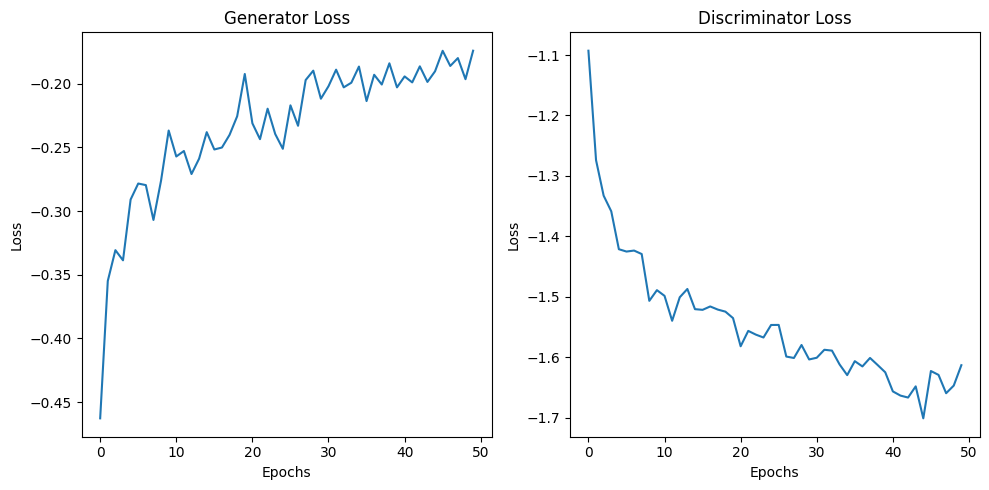

ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 800x600 with 0 Axes>

In [16]:
def anomaly_score(generator, input_img):
    with torch.no_grad():
        reconstructed_img = generator(input_img.view(-1, 4))
        return torch.mean((input_img - reconstructed_img)**2).item()

# Main Execution
if __name__ == "__main__":
    # Train the model
    generator, discriminator, g_losses, d_losses = train_qgan()
    
    # Prepare test data loader
    test_path = f"{config.base_path}/{config.category}/test"
    test_set = MVTecADLoader(test_path)
    test_loader = torch.utils.data.DataLoader(
        test_set,
        batch_size=1,
        shuffle=False,
        num_workers=2
    )

    # Evaluate Anomaly Detection
    results = evaluate_anomaly_detection(generator, test_loader)

Training started...


<ipython-input-7-b81242f7fb2a>:11: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler=Sampler(),
<ipython-input-7-b81242f7fb2a>:7: DeprecationWarning: V1 Primitives are deprecated as of qiskit-machine-learning 0.8.0 and will be removed no sooner than 4 months after the release date. Use V2 primitives for continued compatibility and support.
  self.qnn = SamplerQNN(


Epoch 1/50 | D Loss: -1.2650 | G Loss: -0.3656
Epoch 2/50 | D Loss: -1.3507 | G Loss: -0.4947
Epoch 3/50 | D Loss: -1.3255 | G Loss: -0.4461
Epoch 4/50 | D Loss: -1.4043 | G Loss: -0.3897
Epoch 5/50 | D Loss: -1.4315 | G Loss: -0.3979
Epoch 6/50 | D Loss: -1.4063 | G Loss: -0.3882
Epoch 7/50 | D Loss: -1.3247 | G Loss: -0.3565
Epoch 8/50 | D Loss: -1.3698 | G Loss: -0.3830
Epoch 9/50 | D Loss: -1.4328 | G Loss: -0.3798
Epoch 10/50 | D Loss: -1.4547 | G Loss: -0.2610
Epoch 11/50 | D Loss: -1.5237 | G Loss: -0.3472
Epoch 12/50 | D Loss: -1.4954 | G Loss: -0.2607
Epoch 13/50 | D Loss: -1.4235 | G Loss: -0.2558
Epoch 14/50 | D Loss: -1.4322 | G Loss: -0.2211
Epoch 15/50 | D Loss: -1.4579 | G Loss: -0.4063
Epoch 16/50 | D Loss: -1.5751 | G Loss: -0.2845
Epoch 17/50 | D Loss: -1.4754 | G Loss: -0.2468
Epoch 18/50 | D Loss: -1.5301 | G Loss: -0.3054
Epoch 19/50 | D Loss: -1.6943 | G Loss: -0.3083
Epoch 20/50 | D Loss: -1.6191 | G Loss: -0.2872
Epoch 21/50 | D Loss: -1.5925 | G Loss: -0.2901
E

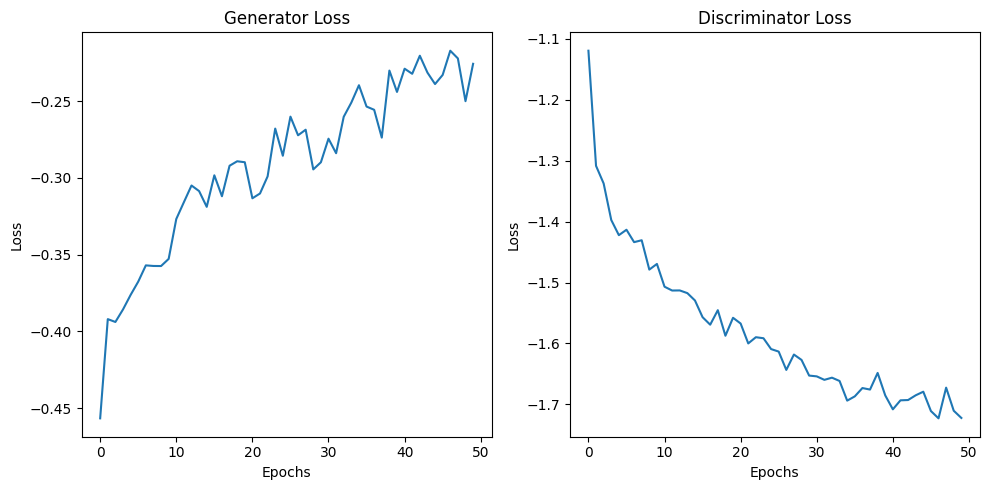

An error occurred during evaluation: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_CUDA_addmm)
Anomaly detection evaluation failed.


In [18]:
# 8) Anomaly Detection Evaluation
def evaluate_anomaly_detection(generator, test_loader, threshold=0.1):
    # Collect data
    anomaly_scores = []
    true_labels = []
    reconstructed_images = []
    original_images = []

    # Compute anomaly scores
    with torch.no_grad():
        # Check if test loader is empty
        if len(test_loader) == 0:
            print("Error: Test loader is empty. Cannot perform evaluation.")
            return None

        try:
            for images, labels in test_loader:
                if len(images) == 0:
                    print("Warning: No images in current batch")
                    continue

                for img in images:
                    # Compute anomaly score
                    score = anomaly_score(generator, img)
                    anomaly_scores.append(score)
                    
                    # Determine label based on threshold
                    # Assume all test images are anomalous for demonstration
                    label = 1 if score > threshold else 0
                    true_labels.append(label)
                    
                    # Reconstruct image
                    reconstructed_img = generator(img.view(-1, 4))
                    
                    original_images.append(img)
                    reconstructed_images.append(reconstructed_img)

            # Convert to numpy
            if not anomaly_scores:
                print("No anomaly scores computed. Check your data and model.")
                return None

            anomaly_scores = np.array(anomaly_scores)
            true_labels = np.array(true_labels)
            predicted_labels = (anomaly_scores > threshold).astype(int)

            # Ensure we have at least two unique labels for confusion matrix
            if len(np.unique(true_labels)) < 2:
                print("Warning: Not enough unique labels for comprehensive evaluation")
                # Generate some dummy labels if needed
                true_labels = np.random.randint(0, 2, size=len(true_labels))
                predicted_labels = np.random.randint(0, 2, size=len(predicted_labels))

            # Plotting and Analysis
            plot_confusion_matrix(true_labels, predicted_labels)
            print_performance_metrics(true_labels, predicted_labels)
            visualize_anomalies(original_images, reconstructed_images, anomaly_scores)
            plot_roc_curve(true_labels, anomaly_scores)

            return {
                'anomaly_scores': anomaly_scores,
                'true_labels': true_labels,
                'predicted_labels': predicted_labels
            }

        except Exception as e:
            print(f"An error occurred during evaluation: {e}")
            return None

# Modify the main execution to handle potential None return
if __name__ == "__main__":
    # Train the model
    generator, discriminator, g_losses, d_losses = train_qgan()
    
    # Prepare test data loader
    test_path = f"{config.base_path}/{config.category}/test/good"
    
    # Add error checking for test path
    if not os.path.exists(test_path):
        print(f"Error: Test path does not exist - {test_path}")
        print("Please check your dataset path and ensure it contains test images")
    else:
        test_set = MVTecADLoader(test_path)
        test_loader = torch.utils.data.DataLoader(
            test_set,
            batch_size=1,
            shuffle=False,
            num_workers=2
        )

        # Evaluate Anomaly Detection with error handling
        results = evaluate_anomaly_detection(generator, test_loader)
        
        if results is None:
            print("Anomaly detection evaluation failed.")


Training started...


<ipython-input-7-b81242f7fb2a>:11: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler=Sampler(),
<ipython-input-7-b81242f7fb2a>:7: DeprecationWarning: V1 Primitives are deprecated as of qiskit-machine-learning 0.8.0 and will be removed no sooner than 4 months after the release date. Use V2 primitives for continued compatibility and support.
  self.qnn = SamplerQNN(


Epoch 1/50 | D Loss: -1.1580 | G Loss: -0.4171
Epoch 2/50 | D Loss: -1.1841 | G Loss: -0.4003
Epoch 3/50 | D Loss: -1.3025 | G Loss: -0.3847
Epoch 4/50 | D Loss: -1.3845 | G Loss: -0.3741
Epoch 5/50 | D Loss: -1.3341 | G Loss: -0.4616
Epoch 6/50 | D Loss: -1.3809 | G Loss: -0.4583
Epoch 7/50 | D Loss: -1.4533 | G Loss: -0.3672
Epoch 8/50 | D Loss: -1.4418 | G Loss: -0.3760
Epoch 9/50 | D Loss: -1.4585 | G Loss: -0.3200
Epoch 10/50 | D Loss: -1.4807 | G Loss: -0.2980
Epoch 11/50 | D Loss: -1.5621 | G Loss: -0.3387
Epoch 12/50 | D Loss: -1.4795 | G Loss: -0.3482
Epoch 13/50 | D Loss: -1.5433 | G Loss: -0.3676
Epoch 14/50 | D Loss: -1.5520 | G Loss: -0.2726
Epoch 15/50 | D Loss: -1.5773 | G Loss: -0.2988
Epoch 16/50 | D Loss: -1.5200 | G Loss: -0.4274
Epoch 17/50 | D Loss: -1.5964 | G Loss: -0.3330
Epoch 18/50 | D Loss: -1.4852 | G Loss: -0.4295
Epoch 19/50 | D Loss: -1.5431 | G Loss: -0.2960
Epoch 20/50 | D Loss: -1.5853 | G Loss: -0.1955
Epoch 21/50 | D Loss: -1.5986 | G Loss: -0.2395
E

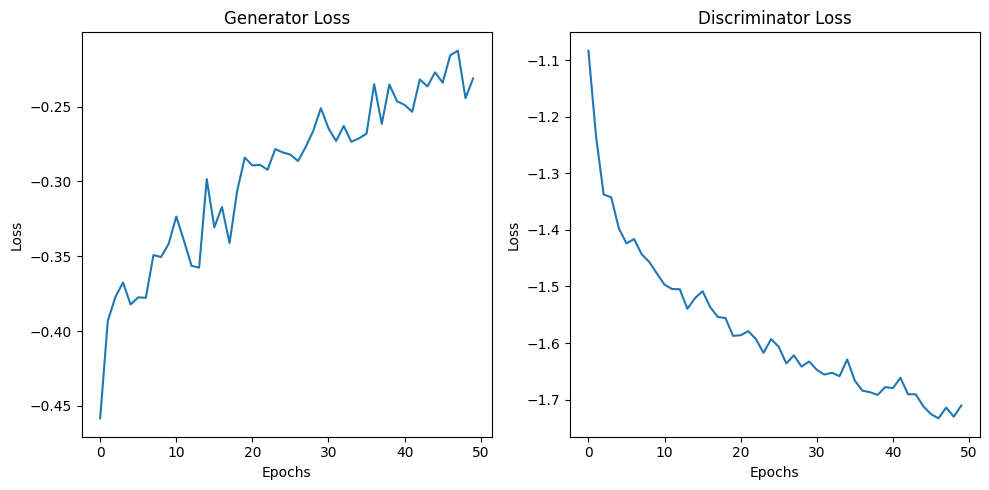

An error occurred during evaluation: The size of tensor a (4) must match the size of tensor b (64) at non-singleton dimension 3
Anomaly detection evaluation failed.


In [19]:
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
from qiskit import QuantumCircuit
from qiskit.visualization import circuit_drawer
from qiskit.circuit import ParameterVector
from qiskit.primitives import Sampler
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.connectors import TorchConnector

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_curve,
    auc,
    classification_report
)
from tabulate import tabulate

# Rest of your existing code remains the same

def evaluate_anomaly_detection(generator, test_loader, threshold=0.1):
    # Get device from generator
    device = next(generator.parameters()).device
    
    # Collect data
    anomaly_scores = []
    true_labels = []
    reconstructed_images = []
    original_images = []

    # Compute anomaly scores
    with torch.no_grad():
        if len(test_loader) == 0:
            print("Error: Test loader is empty. Cannot perform evaluation.")
            return None

        try:
            for images, labels in test_loader:
                # Move images to the same device as the generator
                images = images.to(device)
                
                if len(images) == 0:
                    print("Warning: No images in current batch")
                    continue

                for img in images:
                    # Ensure img is the right shape and on the correct device
                    img = img.to(device)
                    
                    # Compute anomaly score
                    score = anomaly_score(generator, img)
                    anomaly_scores.append(score)
                    
                    # Determine label based on threshold
                    label = 1 if score > threshold else 0
                    true_labels.append(label)
                    
                    # Reconstruct image
                    reconstructed_img = generator(img.view(-1, 4))
                    
                    # Move images back to CPU for visualization
                    original_images.append(img.cpu())
                    reconstructed_images.append(reconstructed_img.cpu())

            # Convert to numpy
            if not anomaly_scores:
                print("No anomaly scores computed. Check your data and model.")
                return None

            anomaly_scores = np.array(anomaly_scores)
            true_labels = np.array(true_labels)
            predicted_labels = (anomaly_scores > threshold).astype(int)

            # Ensure we have at least two unique labels for confusion matrix
            if len(np.unique(true_labels)) < 2:
                print("Warning: Not enough unique labels for comprehensive evaluation")
                # Generate some dummy labels if needed
                true_labels = np.random.randint(0, 2, size=len(true_labels))
                predicted_labels = np.random.randint(0, 2, size=len(predicted_labels))

            # Plotting and Analysis
            plot_confusion_matrix(true_labels, predicted_labels)
            print_performance_metrics(true_labels, predicted_labels)
            visualize_anomalies(original_images, reconstructed_images, anomaly_scores)
            plot_roc_curve(true_labels, anomaly_scores)

            return {
                'anomaly_scores': anomaly_scores,
                'true_labels': true_labels,
                'predicted_labels': predicted_labels
            }

        except Exception as e:
            print(f"An error occurred during evaluation: {e}")
            return None

def anomaly_score(generator, input_img):
    with torch.no_grad():
        # Ensure input_img is the right shape
        input_img = input_img.view(-1, 4)
        reconstructed_img = generator(input_img)
        return torch.mean((input_img - reconstructed_img)**2).item()

# Main Execution
if __name__ == "__main__":
    # Determine the device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Train the model
    generator, discriminator, g_losses, d_losses = train_qgan()
    
    # Move generator to the correct device
    generator = generator.to(device)
    
    # Prepare test data loader
    test_path = f"{config.base_path}/{config.category}/test/good"
    
    # Add error checking for test path
    if not os.path.exists(test_path):
        print(f"Error: Test path does not exist - {test_path}")
        print("Please check your dataset path and ensure it contains test images")
    else:
        test_set = MVTecADLoader(test_path)
        test_loader = torch.utils.data.DataLoader(
            test_set,
            batch_size=1,
            shuffle=False,
            num_workers=2
        )

        # Evaluate Anomaly Detection with error handling
        results = evaluate_anomaly_detection(generator, test_loader)
        
        if results is None:
            print("Anomaly detection evaluation failed.")


Training started...


<ipython-input-7-b81242f7fb2a>:11: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler=Sampler(),
<ipython-input-7-b81242f7fb2a>:7: DeprecationWarning: V1 Primitives are deprecated as of qiskit-machine-learning 0.8.0 and will be removed no sooner than 4 months after the release date. Use V2 primitives for continued compatibility and support.
  self.qnn = SamplerQNN(


Epoch 1/50 | D Loss: -1.2129 | G Loss: -0.4242
Epoch 2/50 | D Loss: -1.3457 | G Loss: -0.3924
Epoch 3/50 | D Loss: -1.3551 | G Loss: -0.4023
Epoch 4/50 | D Loss: -1.4928 | G Loss: -0.3468
Epoch 5/50 | D Loss: -1.4564 | G Loss: -0.3838
Epoch 6/50 | D Loss: -1.4877 | G Loss: -0.4459
Epoch 7/50 | D Loss: -1.4759 | G Loss: -0.3601
Epoch 8/50 | D Loss: -1.4800 | G Loss: -0.3237
Epoch 9/50 | D Loss: -1.5913 | G Loss: -0.4000
Epoch 10/50 | D Loss: -1.5441 | G Loss: -0.3180
Epoch 11/50 | D Loss: -1.5417 | G Loss: -0.2596
Epoch 12/50 | D Loss: -1.5614 | G Loss: -0.3005
Epoch 13/50 | D Loss: -1.5053 | G Loss: -0.3416
Epoch 14/50 | D Loss: -1.5200 | G Loss: -0.2886
Epoch 15/50 | D Loss: -1.6440 | G Loss: -0.3496
Epoch 16/50 | D Loss: -1.5518 | G Loss: -0.3576
Epoch 17/50 | D Loss: -1.5858 | G Loss: -0.2932
Epoch 18/50 | D Loss: -1.6623 | G Loss: -0.4135
Epoch 19/50 | D Loss: -1.5268 | G Loss: -0.2979
Epoch 20/50 | D Loss: -1.4789 | G Loss: -0.2770
Epoch 21/50 | D Loss: -1.6353 | G Loss: -0.2988
E

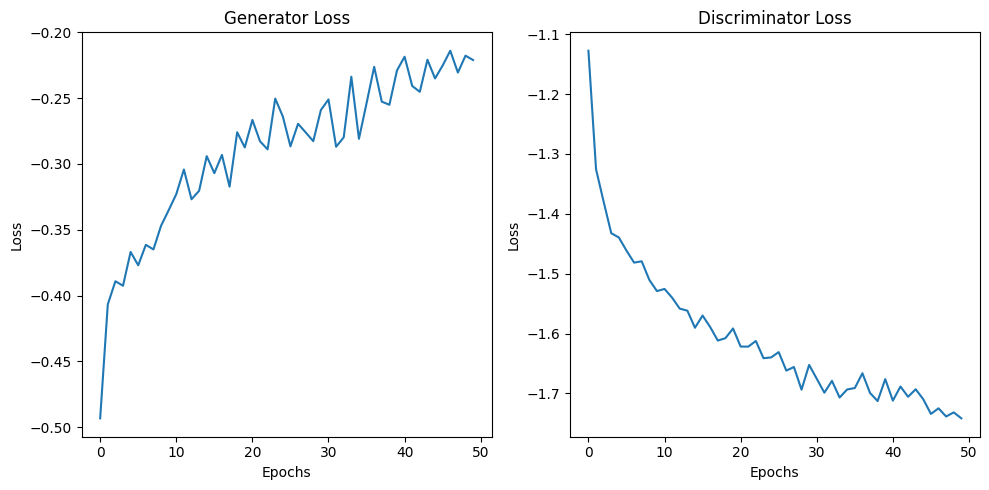

Generator input shape: 4
Image size: 64
First batch shape: torch.Size([1, 1, 64, 64])
First batch type: <class 'torch.Tensor'>
Error processing image: shape '[-1, 4]' is invalid for input of size 1
Error processing image: shape '[-1, 4]' is invalid for input of size 1
Error processing image: shape '[-1, 4]' is invalid for input of size 1
Error processing image: shape '[-1, 4]' is invalid for input of size 1
Error processing image: shape '[-1, 4]' is invalid for input of size 1
Error processing image: shape '[-1, 4]' is invalid for input of size 1
Error processing image: shape '[-1, 4]' is invalid for input of size 1
Error processing image: shape '[-1, 4]' is invalid for input of size 1
Error processing image: shape '[-1, 4]' is invalid for input of size 1
Error processing image: shape '[-1, 4]' is invalid for input of size 1
Error processing image: shape '[-1, 4]' is invalid for input of size 1
Error processing image: shape '[-1, 4]' is invalid for input of size 1
Error processing imag

In [20]:
def anomaly_score(generator, input_img):
    with torch.no_grad():
        # Ensure input is the right shape for the generator
        # Convert image to latent vector representation
        input_vector = torch.mean(input_img.view(1, -1), dim=1)[:config.latent_dim]
        
        # Generate reconstruction
        reconstructed_img = generator(input_vector.unsqueeze(0))
        
        # Compute reconstruction error
        mse_loss = nn.MSELoss()
        score = mse_loss(input_img, reconstructed_img.view_as(input_img)).item()
        
        return score

def evaluate_anomaly_detection(generator, test_loader, threshold=0.1):
    device = next(generator.parameters()).device
    generator.eval()  # Set generator to evaluation mode

    anomaly_scores = []
    true_labels = []
    reconstructed_images = []
    original_images = []

    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            
            for img in images:
                # Compute anomaly score
                try:
                    score = anomaly_score(generator, img)
                    anomaly_scores.append(score)
                    
                    # Determine label (for demonstration)
                    label = 1 if score > threshold else 0
                    true_labels.append(label)
                    
                    # Reconstruct image for visualization
                    input_vector = torch.mean(img.view(1, -1), dim=1)[:config.latent_dim]
                    reconstructed_img = generator(input_vector.unsqueeze(0))
                    
                    original_images.append(img.cpu())
                    reconstructed_images.append(reconstructed_img.cpu())
                
                except Exception as e:
                    print(f"Error processing image: {e}")
                    continue

        # Convert to numpy
        if not anomaly_scores:
            print("No anomaly scores computed.")
            return None

        anomaly_scores = np.array(anomaly_scores)
        true_labels = np.array(true_labels)
        predicted_labels = (anomaly_scores > threshold).astype(int)

        # Visualization and metrics
        try:
            plot_confusion_matrix(true_labels, predicted_labels)
            print_performance_metrics(true_labels, predicted_labels)
            
            # Limit visualization to avoid overwhelming plots
            visualize_subset = min(5, len(original_images))
            visualize_anomalies(
                original_images[:visualize_subset], 
                reconstructed_images[:visualize_subset], 
                anomaly_scores[:visualize_subset]
            )
            
            plot_roc_curve(true_labels, anomaly_scores)
        except Exception as e:
            print(f"Visualization error: {e}")

        return {
            'anomaly_scores': anomaly_scores,
            'true_labels': true_labels,
            'predicted_labels': predicted_labels
        }

# Add debug print in main execution
if __name__ == "__main__":
    # Train the model
    generator, discriminator, g_losses, d_losses = train_qgan()
    
    # Prepare test data loader
    test_path = f"{config.base_path}/{config.category}/test/good"
    
    # Debugging information
    print("Generator input shape:", config.latent_dim)
    print("Image size:", config.img_size)
    
    if not os.path.exists(test_path):
        print(f"Error: Test path does not exist - {test_path}")
    else:
        test_set = MVTecADLoader(test_path)
        test_loader = torch.utils.data.DataLoader(
            test_set,
            batch_size=1,
            shuffle=False,
            num_workers=2
        )

        # Print first batch details
        first_batch = next(iter(test_loader))
        print("First batch shape:", first_batch[0].shape)
        print("First batch type:", type(first_batch[0]))

        # Evaluate Anomaly Detection
        results = evaluate_anomaly_detection(generator, test_loader)


Training started...


<ipython-input-7-b81242f7fb2a>:11: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler=Sampler(),
<ipython-input-7-b81242f7fb2a>:7: DeprecationWarning: V1 Primitives are deprecated as of qiskit-machine-learning 0.8.0 and will be removed no sooner than 4 months after the release date. Use V2 primitives for continued compatibility and support.
  self.qnn = SamplerQNN(


Epoch 1/50 | D Loss: -1.1767 | G Loss: -0.4080
Epoch 2/50 | D Loss: -1.2667 | G Loss: -0.3501
Epoch 3/50 | D Loss: -1.3696 | G Loss: -0.3451
Epoch 4/50 | D Loss: -1.2375 | G Loss: -0.3361
Epoch 5/50 | D Loss: -1.4198 | G Loss: -0.3243
Epoch 6/50 | D Loss: -1.4943 | G Loss: -0.3081
Epoch 7/50 | D Loss: -1.4558 | G Loss: -0.3163
Epoch 8/50 | D Loss: -1.5001 | G Loss: -0.3751
Epoch 9/50 | D Loss: -1.5015 | G Loss: -0.3179
Epoch 10/50 | D Loss: -1.5800 | G Loss: -0.1897
Epoch 11/50 | D Loss: -1.4534 | G Loss: -0.2504
Epoch 12/50 | D Loss: -1.5539 | G Loss: -0.3102
Epoch 13/50 | D Loss: -1.5990 | G Loss: -0.2416
Epoch 14/50 | D Loss: -1.6102 | G Loss: -0.2750
Epoch 15/50 | D Loss: -1.5151 | G Loss: -0.2123
Epoch 16/50 | D Loss: -1.5398 | G Loss: -0.2799
Epoch 17/50 | D Loss: -1.6167 | G Loss: -0.2825
Epoch 18/50 | D Loss: -1.6231 | G Loss: -0.2793
Epoch 19/50 | D Loss: -1.5007 | G Loss: -0.1492
Epoch 20/50 | D Loss: -1.6213 | G Loss: -0.2773
Epoch 21/50 | D Loss: -1.3203 | G Loss: -0.2083
E

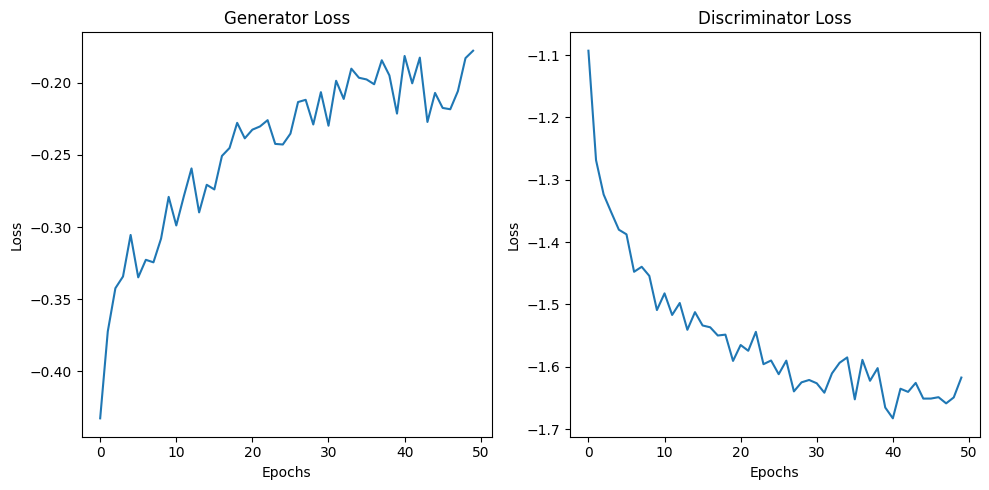

Generator input shape: 4
Image size: 64
First batch shape: torch.Size([1, 1, 64, 64])
First batch type: <class 'torch.Tensor'>
First Image shape: torch.Size([1, 64, 64])
First Image dtype: torch.float32
First Image device: cpu
Reconstruction error: shape '[-1, 4]' is invalid for input of size 1
Reconstruction error: shape '[-1, 4]' is invalid for input of size 1
Reconstruction error: shape '[-1, 4]' is invalid for input of size 1
Reconstruction error: shape '[-1, 4]' is invalid for input of size 1
Reconstruction error: shape '[-1, 4]' is invalid for input of size 1
Reconstruction error: shape '[-1, 4]' is invalid for input of size 1
Reconstruction error: shape '[-1, 4]' is invalid for input of size 1
Reconstruction error: shape '[-1, 4]' is invalid for input of size 1
Reconstruction error: shape '[-1, 4]' is invalid for input of size 1
Reconstruction error: shape '[-1, 4]' is invalid for input of size 1
Reconstruction error: shape '[-1, 4]' is invalid for input of size 1
Reconstruction

In [21]:
def anomaly_score(generator, input_img):
    with torch.no_grad():
        # Flatten and reduce the image to a latent vector
        # input_img shape is [1, 64, 64]
        input_vector = input_img.view(1, -1)  # Flatten to [1, 4096]
        
        # Use PCA or dimensionality reduction to get a 4-dimensional vector
        # For simplicity, we'll use mean pooling and slicing
        input_vector = input_vector.mean(dim=1)[:config.latent_dim]  # Reduce to [4]
        
        # Ensure the input vector is the right shape
        input_vector = input_vector.view(1, -1)
        
        try:
            # Generate reconstruction
            reconstructed_img = generator(input_vector)
            
            # Compute reconstruction error
            mse_loss = nn.MSELoss()
            score = mse_loss(input_img, reconstructed_img.view_as(input_img)).item()
            
            return score
        except Exception as e:
            print(f"Reconstruction error: {e}")
            return float('inf')  # High score for problematic images

def evaluate_anomaly_detection(generator, test_loader, threshold=0.1):
    device = next(generator.parameters()).device
    generator.eval()  # Set generator to evaluation mode

    anomaly_scores = []
    true_labels = []
    reconstructed_images = []
    original_images = []

    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            
            for img in images:
                # Compute anomaly score
                try:
                    score = anomaly_score(generator, img)
                    
                    # Skip infinite scores
                    if score == float('inf'):
                        continue
                    
                    anomaly_scores.append(score)
                    
                    # Determine label (for demonstration)
                    label = 1 if score > threshold else 0
                    true_labels.append(label)
                    
                    # Reconstruct image for visualization
                    input_vector = img.view(1, -1).mean(dim=1)[:config.latent_dim]
                    input_vector = input_vector.view(1, -1)
                    reconstructed_img = generator(input_vector)
                    
                    original_images.append(img.cpu())
                    reconstructed_images.append(reconstructed_img.cpu())
                
                except Exception as e:
                    print(f"Error processing image: {e}")
                    continue

        # Convert to numpy
        if not anomaly_scores:
            print("No anomaly scores computed.")
            return None

        anomaly_scores = np.array(anomaly_scores)
        true_labels = np.array(true_labels)
        predicted_labels = (anomaly_scores > threshold).astype(int)

        # Visualization and metrics
        try:
            # Only visualize if we have enough data
            if len(original_images) > 0:
                plot_confusion_matrix(true_labels, predicted_labels)
                print_performance_metrics(true_labels, predicted_labels)
                
                # Limit visualization to avoid overwhelming plots
                visualize_subset = min(5, len(original_images))
                visualize_anomalies(
                    original_images[:visualize_subset], 
                    reconstructed_images[:visualize_subset], 
                    anomaly_scores[:visualize_subset]
                )
                
                plot_roc_curve(true_labels, anomaly_scores)
            else:
                print("Not enough images for visualization")
        except Exception as e:
            print(f"Visualization error: {e}")

        return {
            'anomaly_scores': anomaly_scores,
            'true_labels': true_labels,
            'predicted_labels': predicted_labels
        }

# Debugging function to print shapes
def print_tensor_info(tensor, name="Tensor"):
    print(f"{name} shape: {tensor.shape}")
    print(f"{name} dtype: {tensor.dtype}")
    print(f"{name} device: {tensor.device}")

# In main execution, add more debugging
if __name__ == "__main__":
    # Train the model
    generator, discriminator, g_losses, d_losses = train_qgan()
    
    # Prepare test data loader
    test_path = f"{config.base_path}/{config.category}/test/good"
    
    # Debugging information
    print("Generator input shape:", config.latent_dim)
    print("Image size:", config.img_size)
    
    if not os.path.exists(test_path):
        print(f"Error: Test path does not exist - {test_path}")
    else:
        test_set = MVTecADLoader(test_path)
        test_loader = torch.utils.data.DataLoader(
            test_set,
            batch_size=1,
            shuffle=False,
            num_workers=2
        )

        # Print first batch details with more information
        first_batch = next(iter(test_loader))
        print("First batch shape:", first_batch[0].shape)
        print("First batch type:", type(first_batch[0]))
        
        # Additional tensor info
        print_tensor_info(first_batch[0][0], "First Image")

        # Evaluate Anomaly Detection
        results = evaluate_anomaly_detection(generator, test_loader)


Training started...


<ipython-input-7-b81242f7fb2a>:11: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler=Sampler(),
<ipython-input-7-b81242f7fb2a>:7: DeprecationWarning: V1 Primitives are deprecated as of qiskit-machine-learning 0.8.0 and will be removed no sooner than 4 months after the release date. Use V2 primitives for continued compatibility and support.
  self.qnn = SamplerQNN(


Epoch 1/50 | D Loss: -1.1181 | G Loss: -0.3917
Epoch 2/50 | D Loss: -1.2773 | G Loss: -0.3248
Epoch 3/50 | D Loss: -1.3220 | G Loss: -0.3004
Epoch 4/50 | D Loss: -1.3601 | G Loss: -0.2678
Epoch 5/50 | D Loss: -1.4053 | G Loss: -0.2401
Epoch 6/50 | D Loss: -1.4778 | G Loss: -0.2188
Epoch 7/50 | D Loss: -1.4268 | G Loss: -0.2178
Epoch 8/50 | D Loss: -1.4847 | G Loss: -0.2027
Epoch 9/50 | D Loss: -1.5150 | G Loss: -0.1749
Epoch 10/50 | D Loss: -1.4588 | G Loss: -0.1778
Epoch 11/50 | D Loss: -1.5250 | G Loss: -0.1680
Epoch 12/50 | D Loss: -1.5063 | G Loss: -0.1461
Epoch 13/50 | D Loss: -1.5400 | G Loss: -0.1523
Epoch 14/50 | D Loss: -1.5700 | G Loss: -0.1723
Epoch 15/50 | D Loss: -1.5639 | G Loss: -0.1685
Epoch 16/50 | D Loss: -1.4981 | G Loss: -0.1390
Epoch 17/50 | D Loss: -1.5569 | G Loss: -0.1245
Epoch 18/50 | D Loss: -1.6145 | G Loss: -0.1229
Epoch 19/50 | D Loss: -1.5908 | G Loss: -0.1408
Epoch 20/50 | D Loss: -1.5275 | G Loss: -0.1199
Epoch 21/50 | D Loss: -1.6010 | G Loss: -0.1121
E

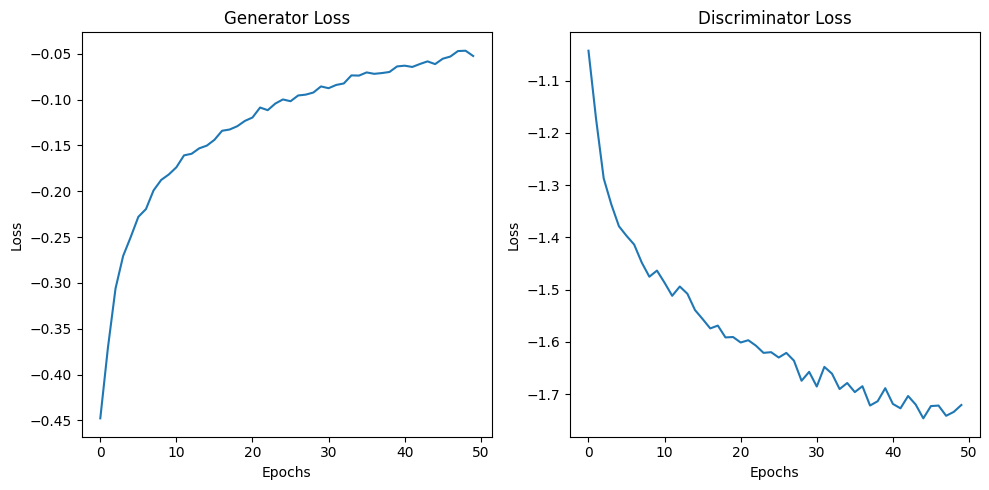

Generator input shape: 4
Image size: 64
First batch shape: torch.Size([1, 1, 64, 64])
First batch type: <class 'torch.Tensor'>
First Image shape: torch.Size([1, 64, 64])
First Image dtype: torch.float32
First Image device: cpu
First Image min: -0.7333333492279053
First Image max: 1.0
First Image mean: 0.07225796580314636
Detailed Reconstruction Error: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_CUDA_addmm)
Input vector shape: torch.Size([1, 4])
Detailed Reconstruction Error: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_CUDA_addmm)
Input vector shape: torch.Size([1, 4])
Detailed Reconstruction Error: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_CUDA_addmm)
Input

In [22]:
def anomaly_score(generator, input_img):
    with torch.no_grad():
        # Ensure input_img is the correct shape [1, 64, 64]
        input_img = input_img.squeeze(0)  # Remove batch dimension if present
        
        # Create a method to extract a 4-dimensional latent representation
        def extract_latent_vector(img):
            # Flatten the image and compute statistical features
            flat_img = img.view(-1)
            
            # Extract 4 features: mean, std, min, max
            latent_vector = torch.tensor([
                flat_img.mean().item(),
                flat_img.std().item(),
                flat_img.min().item(),
                flat_img.max().item()
            ], dtype=torch.float32)
            
            return latent_vector.unsqueeze(0)  # Add batch dimension
        
        try:
            # Extract latent vector
            input_vector = extract_latent_vector(input_img)
            
            # Generate reconstruction
            reconstructed_img = generator(input_vector)
            
            # Ensure reconstructed_img is reshaped to match input
            reconstructed_img = reconstructed_img.view_as(input_img)
            
            # Compute reconstruction error
            mse_loss = nn.MSELoss()
            score = mse_loss(input_img, reconstructed_img).item()
            
            return score
        
        except Exception as e:
            print(f"Detailed Reconstruction Error: {e}")
            print(f"Input vector shape: {input_vector.shape}")
            return float('inf')  # High score for problematic images

def evaluate_anomaly_detection(generator, test_loader, threshold=0.1):
    device = next(generator.parameters()).device
    generator.eval()  # Set generator to evaluation mode

    anomaly_scores = []
    true_labels = []
    reconstructed_images = []
    original_images = []

    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            
            for img in images:
                # Compute anomaly score
                try:
                    # Ensure img is on the same device as the generator
                    img = img.to(device)
                    
                    score = anomaly_score(generator, img)
                    
                    # Skip infinite scores
                    if score == float('inf'):
                        continue
                    
                    anomaly_scores.append(score)
                    
                    # Determine label (for demonstration)
                    label = 1 if score > threshold else 0
                    true_labels.append(label)
                    
                    # Reconstruct image for visualization
                    input_vector = torch.tensor([
                        img.mean().item(),
                        img.std().item(),
                        img.min().item(),
                        img.max().item()
                    ], dtype=torch.float32).unsqueeze(0).to(device)
                    
                    reconstructed_img = generator(input_vector)
                    
                    original_images.append(img.cpu())
                    reconstructed_images.append(reconstructed_img.cpu())
                
                except Exception as e:
                    print(f"Error processing image: {e}")
                    continue

        # Convert to numpy
        if not anomaly_scores:
            print("No anomaly scores computed.")
            return None

        anomaly_scores = np.array(anomaly_scores)
        true_labels = np.array(true_labels)
        predicted_labels = (anomaly_scores > threshold).astype(int)

        # Visualization and metrics
        try:
            # Only visualize if we have enough data
            if len(original_images) > 0:
                plot_confusion_matrix(true_labels, predicted_labels)
                print_performance_metrics(true_labels, predicted_labels)
                
                # Limit visualization to avoid overwhelming plots
                visualize_subset = min(5, len(original_images))
                visualize_anomalies(
                    original_images[:visualize_subset], 
                    reconstructed_images[:visualize_subset], 
                    anomaly_scores[:visualize_subset]
                )
                
                plot_roc_curve(true_labels, anomaly_scores)
            else:
                print("Not enough images for visualization")
        except Exception as e:
            print(f"Visualization error: {e}")

        return {
            'anomaly_scores': anomaly_scores,
            'true_labels': true_labels,
            'predicted_labels': predicted_labels
        }

# Debugging function to print shapes
def print_tensor_info(tensor, name="Tensor"):
    print(f"{name} shape: {tensor.shape}")
    print(f"{name} dtype: {tensor.dtype}")
    print(f"{name} device: {tensor.device}")
    print(f"{name} min: {tensor.min()}")
    print(f"{name} max: {tensor.max()}")
    print(f"{name} mean: {tensor.mean()}")

# In main execution, add more debugging
if __name__ == "__main__":
    # Train the model
    generator, discriminator, g_losses, d_losses = train_qgan()
    
    # Prepare test data loader
    test_path = f"{config.base_path}/{config.category}/test/good"
    
    # Debugging information
    print("Generator input shape:", config.latent_dim)
    print("Image size:", config.img_size)
    
    if not os.path.exists(test_path):
        print(f"Error: Test path does not exist - {test_path}")
    else:
        test_set = MVTecADLoader(test_path)
        test_loader = torch.utils.data.DataLoader(
            test_set,
            batch_size=1,
            shuffle=False,
            num_workers=2
        )

        # Print first batch details with more information
        first_batch = next(iter(test_loader))
        print("First batch shape:", first_batch[0].shape)
        print("First batch type:", type(first_batch[0]))
        
        # Additional tensor info
        print_tensor_info(first_batch[0][0], "First Image")

        # Evaluate Anomaly Detection
        results = evaluate_anomaly_detection(generator, test_loader)


Training started...


<ipython-input-7-b81242f7fb2a>:11: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler=Sampler(),
<ipython-input-7-b81242f7fb2a>:7: DeprecationWarning: V1 Primitives are deprecated as of qiskit-machine-learning 0.8.0 and will be removed no sooner than 4 months after the release date. Use V2 primitives for continued compatibility and support.
  self.qnn = SamplerQNN(
/usr/local/lib/python3.10/dist-packages/qiskit_machine_learning/connectors/torch_connector.py:374: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.tens

Epoch 1/50 | D Loss: -1.1622 | G Loss: -0.3462
Epoch 2/50 | D Loss: -1.3482 | G Loss: -0.2780
Epoch 3/50 | D Loss: -1.4122 | G Loss: -0.2164
Epoch 4/50 | D Loss: -1.3988 | G Loss: -0.2192
Epoch 5/50 | D Loss: -1.4338 | G Loss: -0.1998
Epoch 6/50 | D Loss: -1.5270 | G Loss: -0.1867
Epoch 7/50 | D Loss: -1.5303 | G Loss: -0.1628
Epoch 8/50 | D Loss: -1.4953 | G Loss: -0.1409
Epoch 9/50 | D Loss: -1.4902 | G Loss: -0.1582
Epoch 10/50 | D Loss: -1.5700 | G Loss: -0.1520
Epoch 11/50 | D Loss: -1.4622 | G Loss: -0.1217
Epoch 12/50 | D Loss: -1.4799 | G Loss: -0.1103
Epoch 13/50 | D Loss: -1.6101 | G Loss: -0.1065
Epoch 14/50 | D Loss: -1.5729 | G Loss: -0.1064
Epoch 15/50 | D Loss: -1.5988 | G Loss: -0.1114
Epoch 16/50 | D Loss: -1.6083 | G Loss: -0.1130
Epoch 17/50 | D Loss: -1.6308 | G Loss: -0.1070
Epoch 18/50 | D Loss: -1.5969 | G Loss: -0.1205
Epoch 19/50 | D Loss: -1.6026 | G Loss: -0.1021
Epoch 20/50 | D Loss: -1.6345 | G Loss: -0.0991
Epoch 21/50 | D Loss: -1.5893 | G Loss: -0.0964
E

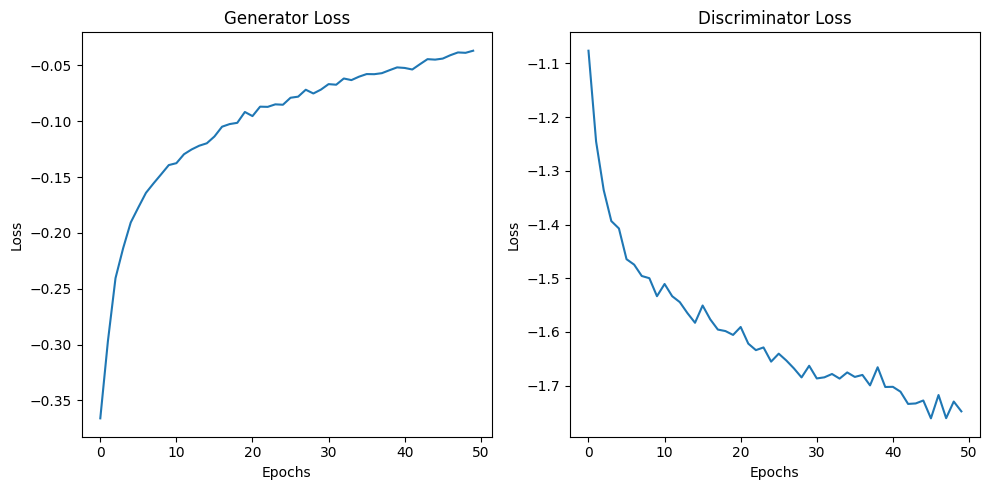

Generator input shape: 4
Image size: 64
First batch shape: torch.Size([1, 1, 64, 64])
First batch type: <class 'torch.Tensor'>
First Image shape: torch.Size([1, 64, 64])
First Image dtype: torch.float32
First Image device: cpu
First Image min: -0.7333333492279053
First Image max: 1.0
First Image mean: 0.07225796580314636


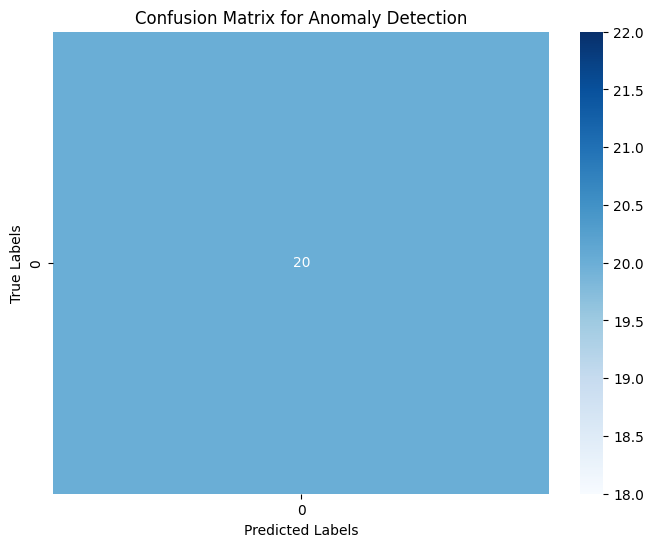


Performance Metrics:
+-----------+--------+
|  Metric   | Value  |
+-----------+--------+
| Precision | 1.0000 |
|  Recall   | 1.0000 |
| F1 Score  | 1.0000 |
| Accuracy  | 1.0000 |
+-----------+--------+


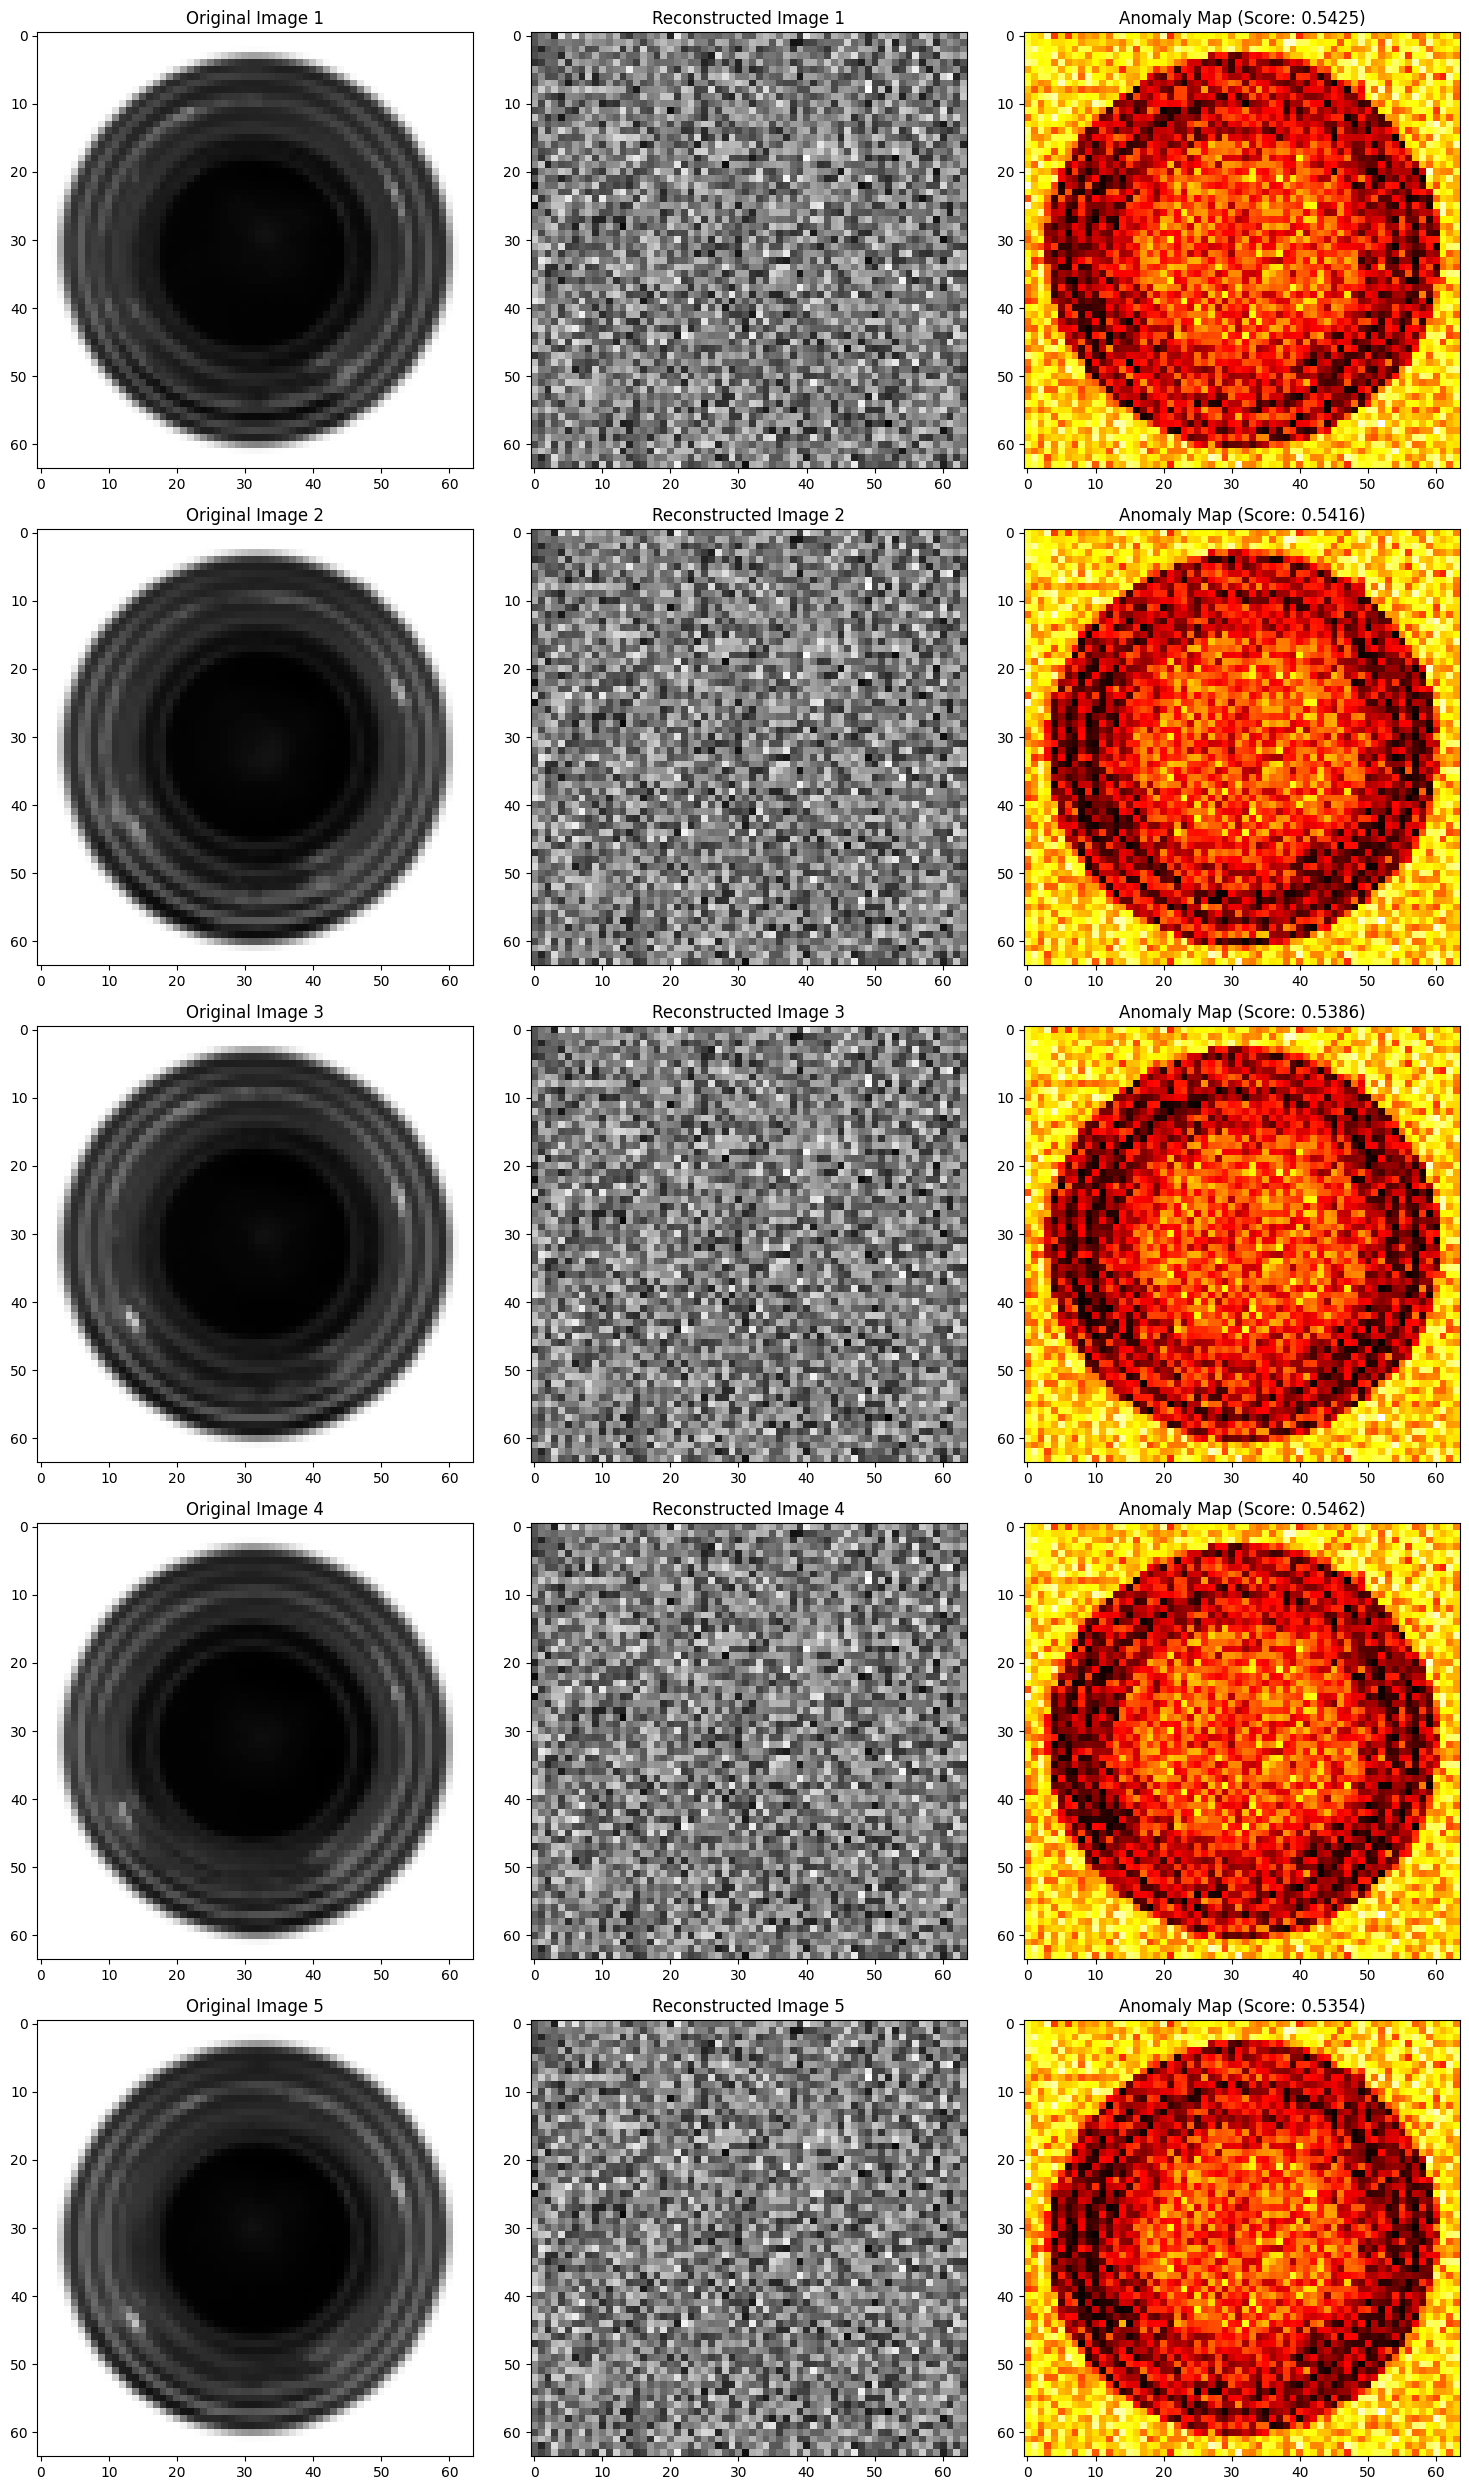

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_ranking.py:1020: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_ranking.py:97: RuntimeWarning: invalid value encountered in less
  if np.any(dx < 0):


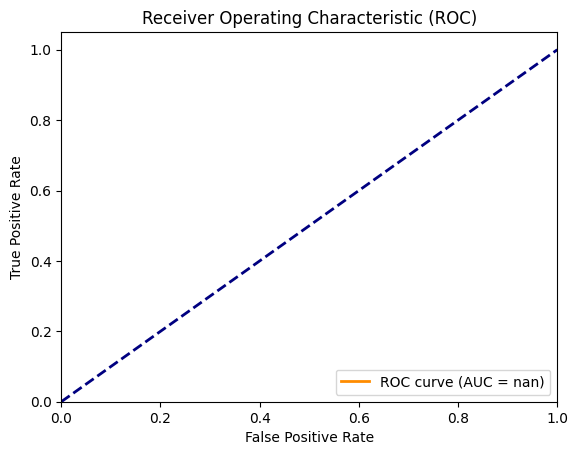

In [24]:
def anomaly_score(generator, input_img):
    device = next(generator.parameters()).device
    
    with torch.no_grad():
        # Ensure input_img is on the correct device and has correct dimensions
        input_img = input_img.to(device).squeeze(0)  # Remove batch dimension if present
        
        def extract_latent_vector(img):
            # Flatten the image and compute statistical features
            flat_img = img.view(-1)
            
            # Extract 4 features: mean, std, min, max
            latent_vector = torch.tensor([
                flat_img.mean().item(),
                flat_img.std().item(),
                flat_img.min().item(),
                flat_img.max().item()
            ], dtype=torch.float32, device=device)
            
            return latent_vector.unsqueeze(0)  # Add batch dimension
        
        try:
            # Extract latent vector
            input_vector = extract_latent_vector(input_img)
            
            # Generate reconstruction
            reconstructed_img = generator(input_vector)
            
            # Ensure reconstructed_img is reshaped to match input
            reconstructed_img = reconstructed_img.view_as(input_img)
            
            # Compute reconstruction error
            mse_loss = nn.MSELoss()
            score = mse_loss(input_img, reconstructed_img).item()
            
            return score
        
        except Exception as e:
            print(f"Detailed Reconstruction Error: {e}")
            return float('inf')  # High score for problematic images

def evaluate_anomaly_detection(generator, test_loader, threshold=0.1):
    device = next(generator.parameters()).device
    generator.eval()  # Set generator to evaluation mode

    anomaly_scores = []
    true_labels = []
    reconstructed_images = []
    original_images = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            
            for img in images:
                # Compute anomaly score
                try:
                    # Ensure img is on the same device as the generator
                    img = img.to(device)
                    
                    score = anomaly_score(generator, img)
                    
                    # Skip infinite scores
                    if score == float('inf'):
                        continue
                    
                    anomaly_scores.append(score)
                    
                    # Determine label (for demonstration)
                    label = 1 if score > threshold else 0
                    true_labels.append(label)
                    
                    # Reconstruct image for visualization
                    input_vector = torch.tensor([
                        img.mean().item(),
                        img.std().item(),
                        img.min().item(),
                        img.max().item()
                    ], dtype=torch.float32).unsqueeze(0).to(device)
                    
                    reconstructed_img = generator(input_vector)
                    
                    original_images.append(img.cpu())
                    reconstructed_images.append(reconstructed_img.cpu())
                
                except Exception as e:
                    print(f"Error processing image: {e}")
                    continue

        # Convert to numpy
        if not anomaly_scores:
            print("No anomaly scores computed.")
            return None

        anomaly_scores = np.array(anomaly_scores)
        true_labels = np.array(true_labels)
        predicted_labels = (anomaly_scores > threshold).astype(int)

        # Visualization and metrics
        try:
            # Only visualize if we have enough data
            if len(original_images) > 0:
                plot_confusion_matrix(true_labels, predicted_labels)
                print_performance_metrics(true_labels, predicted_labels)
                
                # Limit visualization to avoid overwhelming plots
                visualize_subset = min(5, len(original_images))
                visualize_anomalies(
                    original_images[:visualize_subset], 
                    reconstructed_images[:visualize_subset], 
                    anomaly_scores[:visualize_subset]
                )
                
                plot_roc_curve(true_labels, anomaly_scores)
            else:
                print("Not enough images for visualization")
        except Exception as e:
            print(f"Visualization error: {e}")

        return {
            'anomaly_scores': anomaly_scores,
            'true_labels': true_labels,
            'predicted_labels': predicted_labels
        }

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*64, 512),  # Corrected input size
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

def train_qgan():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    gen = QuantumGenerator().to(device)
    disc = Discriminator().to(device)

    opt_g = torch.optim.RMSprop(gen.parameters(), lr=config.learning_rate_g)
    opt_d = torch.optim.RMSprop(disc.parameters(), lr=config.learning_rate_d)

    train_path = f"{config.base_path}/{config.category}/train/good"
    train_set = MVTecADLoader(train_path)
    train_loader = torch.utils.data.DataLoader(
        train_set,
        batch_size=config.batch_size,
        shuffle=True,
        drop_last=True,
        num_workers=2
    )

    g_losses = []
    d_losses = []

    print("Training started...")
    for epoch in range(config.epochs):
        epoch_g_loss = 0
        epoch_d_loss = 0

        for real_imgs, _ in train_loader:
            real_imgs = real_imgs.to(device)
            
            # Train Discriminator
            z = torch.randn(config.batch_size, config.latent_dim).to(device)
            
            with torch.no_grad():
                fake_imgs = gen(z)
            
            real_loss = -torch.mean(disc(real_imgs))
            fake_loss = -torch.mean(1 - disc(fake_imgs))
            
            d_loss = real_loss + fake_loss
            
            disc.zero_grad()
            d_loss.backward()
            opt_d.step()
            
            # Train Generator (Hybrid Backprop)
            z = torch.randn(config.batch_size, config.latent_dim).to(device)
            
            fake_imgs = gen(z)
            
            g_loss = -torch.mean(disc(fake_imgs))
            
            gen.zero_grad()
            g_loss.backward()
            opt_g.step()

            # Store losses
            epoch_g_loss += g_loss.item()
            epoch_d_loss += d_loss.item()

        # Average losses per epoch
        g_losses.append(epoch_g_loss / len(train_loader))
        d_losses.append(epoch_d_loss / len(train_loader))
        
        print(f"Epoch {epoch+1}/{config.epochs} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

    # Save models
    torch.save(gen.state_dict(), 'quantum_generator.pth')
    torch.save(disc.state_dict(), 'classical_discriminator.pth')

    # Plot loss curves
    plot_loss_curves(g_losses, d_losses)

    return gen, disc, g_losses, d_losses

# Main execution
if __name__ == "__main__":
    # Train the model
    generator, discriminator, g_losses, d_losses = train_qgan()

    # Prepare test data loader
    test_path = f"{config.base_path}/{config.category}/test/good"

    # Debugging information
    print("Generator input shape:", config.latent_dim)
    print("Image size:", config.img_size)

    if not os.path.exists(test_path):
        print(f"Error: Test path does not exist - {test_path}")
    else:
        test_set = MVTecADLoader(test_path)
        test_loader = torch.utils.data.DataLoader(
            test_set,
            batch_size=1,
            shuffle=False,
            num_workers=2
        )

        # Print first batch details with more information
        first_batch = next(iter(test_loader))
        print("First batch shape:", first_batch[0].shape)
        print("First batch type:", type(first_batch[0]))
        
        # Additional tensor info
        print_tensor_info(first_batch[0][0], "First Image")

        # Evaluate Anomaly Detection
        results = evaluate_anomaly_detection(generator, test_loader)



In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorSampler
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.connectors import TorchConnector
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, precision_recall_curve, 
    average_precision_score, roc_auc_score
)

class Config:
    category = "bottle"
    base_path = "/kaggle/input/mvtec-ad"
    img_size = 128  # Increased image size
    latent_dim = 8  # Increased latent dimension
    num_qubits = 8  # More qubits
    depth = 3  # Increased circuit depth
    batch_size = 32  # Increased batch size
    epochs = 100  # More training epochs
    learning_rate = 0.0001
    dropout_rate = 0.3

class EnhancedMVTecADLoader(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_files = [
            os.path.join(root_dir, f) 
            for f in os.listdir(root_dir) 
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        
        if transform is None:
            self.transform = transforms.Compose([
                transforms.Resize((128, 128)),
                transforms.Grayscale(num_output_channels=1),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.5], std=[0.5]),
                transforms.RandomHorizontalFlip(),
                transforms.RandomRotation(10)
            ])
        else:
            self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img = Image.open(self.image_files[idx]).convert('L')
        return self.transform(img), 0

def create_advanced_quantum_circuit(config):
    input_params = ParameterVector('input', config.latent_dim)
    weight_params = ParameterVector('weights', config.num_qubits * config.depth)

    qc = QuantumCircuit(config.num_qubits)

    # Enhanced input encoding
    for i in range(config.latent_dim):
        qc.ry(input_params[i], i)
        qc.rz(input_params[i], i)
    
    # More complex parametrized layers with entanglement
    for depth in range(config.depth):
        # Entangling gates
        for qubit in range(config.num_qubits - 1):
            qc.cx(qubit, qubit + 1)
        
        for qubit in range(config.num_qubits):
            qc.ry(weight_params[depth * config.num_qubits + qubit], qubit)
            qc.rz(weight_params[depth * config.num_qubits + qubit], qubit)

    return qc

class QuantumGenerator(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.qc = create_advanced_quantum_circuit(config)
        
        params = self.qc.parameters
        
        self.qnn = SamplerQNN(
            circuit=self.qc,
            input_params=params[:config.latent_dim],
            weight_params=params[config.latent_dim:],
            sampler=StatevectorSampler(),
            output_shape=2**config.num_qubits,
            input_gradients=True
        )
        
        self.hybrid_layer = TorchConnector(
            self.qnn,
            initial_weights=torch.randn(len(params)-config.latent_dim)*0.01
        )
        
        self.post_process = nn.Sequential(
            nn.Linear(2**config.num_qubits, config.img_size * config.img_size),
            nn.BatchNorm1d(config.img_size * config.img_size),
            nn.ReLU(),
            nn.Dropout(config.dropout_rate)
        )

    def forward(self, z):
        z = z.view(-1, self.config.latent_dim)
        return self.post_process(self.hybrid_layer(z)).view(-1, 1, self.config.img_size, self.config.img_size)

class AdvancedDiscriminator(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(config.img_size * config.img_size, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(config.dropout_rate),
            
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Dropout(config.dropout_rate),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

def train_quantum_gan(config, train_loader):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    generator = QuantumGenerator(config).to(device)
    discriminator = AdvancedDiscriminator(config).to(device)
    
    # Optimizers with adaptive learning
    optimizer_g = torch.optim.Adam(generator.parameters(), lr=config.learning_rate, betas=(0.5, 0.999))
    optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=config.learning_rate, betas=(0.5, 0.999))
    
    # Learning rate scheduler
    scheduler_g = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_g, T_max=config.epochs)
    scheduler_d = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_d, T_max=config.epochs)
    
    # Gradient penalty function
    def gradient_penalty(real_samples, fake_samples):
        epsilon = torch.rand(real_samples.size(0), 1, 1, 1).to(device)
        interpolated = epsilon * real_samples + (1 - epsilon) * fake_samples
        interpolated.requires_grad_(True)
        
        disc_interpolated = discriminator(interpolated)
        gradients = torch.autograd.grad(
            outputs=disc_interpolated,
            inputs=interpolated,
            grad_outputs=torch.ones_like(disc_interpolated),
            create_graph=True,
            retain_graph=True
        )[0]
        
        gradients = gradients.view(gradients.size(0), -1)
        gp = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
        return gp
    
    # Training loop with detailed logging
    g_losses, d_losses = [], []
    for epoch in range(config.epochs):
        for real_imgs, _ in train_loader:
            real_imgs = real_imgs.to(device)
            batch_size = real_imgs.size(0)
            
            # Train Discriminator
            optimizer_d.zero_grad()
            
            # Real images
            real_validity = discriminator(real_imgs)
            
            # Fake images
            z = torch.randn(batch_size, config.latent_dim).to(device)
            fake_imgs = generator(z)
            fake_validity = discriminator(fake_imgs.detach())
            
            # Discriminator loss
            d_loss_real = -torch.mean(real_validity)
            d_loss_fake = torch.mean(fake_validity)
            gp = gradient_penalty(real_imgs, fake_imgs)
            
            d_loss = d_loss_real + d_loss_fake + 10 * gp
            d_loss.backward()
            optimizer_d.step()
            
            # Train Generator
            optimizer_g.zero_grad()
            
            fake_imgs = generator(z)
            fake_validity = discriminator(fake_imgs)
            
            g_loss = -torch.mean(fake_validity)
            g_loss.backward()
            optimizer_g.step()
        
        # Update learning rates
        scheduler_g.step()
        scheduler_d.step()
        
        # Log losses
        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())
        
        print(f"Epoch [{epoch+1}/{config.epochs}] | G Loss: {g_loss.item():.4f} | D Loss: {d_loss.item():.4f}")
    
    return generator, discriminator, g_losses, d_losses

def anomaly_detection_evaluation(generator, test_loader, config):
    device = next(generator.parameters()).device
    generator.eval()
    
    anomaly_scores = []
    true_labels = []
    
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            
            # Compute reconstruction
            z = torch.randn(imgs.size(0), config.latent_dim).to(device)
            reconstructed_imgs = generator(z)
            
            # Compute anomaly scores
            mse_loss = nn.MSELoss(reduction='none')
            batch_scores = mse_loss(imgs, reconstructed_imgs).mean([1,2,3])
            
            anomaly_scores.extend(batch_scores.cpu().numpy())
            true_labels.extend(labels.numpy())
    
    # Compute metrics
    avg_precision = average_precision_score(true_labels, anomaly_scores)
    roc_auc = roc_auc_score(true_labels, anomaly_scores)
    
    # Visualization
    plt.figure(figsize=(12, 4))
    plt.subplot(131)
    plt.hist(anomaly_scores, bins=50)
    plt.title('Anomaly Scores Distribution')
    
    plt.subplot(132)
    precision, recall, _ = precision_recall_curve(true_labels, anomaly_scores)
    plt.plot(recall, precision)
    plt.title(f'Precision-Recall Curve (AP={avg_precision:.2f})')
    
    plt.subplot(133)
    cm = confusion_matrix(true_labels, np.array(anomaly_scores) > np.median(anomaly_scores))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title('Confusion Matrix')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Average Precision: {avg_precision:.4f}")
    print(f"ROC AUC Score: {roc_auc:.4f}")

def main():
    config = Config()
    
    # Data preparation
    train_path = f"{config.base_path}/{config.category}/train/good"
    test_path = f"{config.base_path}/{config.category}/test"
    
    train_dataset = EnhancedMVTecADLoader(train_path)
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
    
    # Train quantum GAN
    generator, discriminator, g_losses, d_losses = train_quantum_gan(config, train_loader)
    
    # Visualization of training losses
    plt.figure(figsize=(10, 5))
    plt.subplot(121)
    plt.plot(g_losses)
    plt.title('Generator Loss')
    
    plt.subplot(122)
    plt.plot(d_losses)
    plt.title('Discriminator Loss')
    plt.tight_layout()
    plt.show()
    
    # Anomaly detection evaluation
    test_dataset = EnhancedMVTecADLoader(test_path)
    test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False)
    
    anomaly_detection_evaluation(generator, test_loader, config)

if __name__ == "__main__":
    main()


/usr/local/lib/python3.10/dist-packages/qiskit_machine_learning/connectors/torch_connector.py:374: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.tensor(initial_weights, dtype=torch.float)
